# Statistical Pattern Recognition - Computer Assignment #3

**Complete audited implementation for Google Colab and Python**

This notebook implements the assignment exactly around the algorithms named in the original handout:

1. Perceptron: ω1 vs. ω2 and ω3 vs. ω2, including convergence iterations and comparison.
2. Least-squares (LS) criterion: ω1 vs. ω2 and ω3 vs. ω2.
3. Multi-category Logistic Discrimination:
   - one-vs-rest: ωi vs. not ωi for i = 1, 2, 3, 4;
   - one-vs-one: ωi vs. ωj for all class pairs;
   - ambiguity analysis over the 2-D feature space.

The assignment PDF supplies the authoritative training table, so the notebook preserves that dataset exactly rather than substituting an unrelated internet dataset. A clean CSV copy is generated automatically for download/reproducibility.

> **Important numerical note:** unregularized logistic maximum-likelihood training can fail to reach a finite optimum on linearly separable data. The implementation reports this honestly through a `converged` flag and a maximum-iteration budget instead of silently claiming convergence.

## Audit status

The uploaded notebook contained only a single implementation for the Perceptron experiment on ω1 and ω2. It did not implement the remaining assignment sections (Perceptron ω3/ω2, LS, or multi-category logistic discrimination), did not save reproducible result artifacts, and did not provide a one-click Colab export workflow.

This revised notebook therefore expands the implementation to the **entire assignment**, while preserving the original methods and the exact assignment dataset.

In [1]:
# Environment and reproducibility
import math
import shutil
import sys
import zipfile
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

try:
    from IPython.display import display
except ImportError:
    display = print

print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Random seed: {SEED}")

Python: 3.13.15
NumPy: 2.1.3
pandas: 2.2.3
Matplotlib: 3.10.0
Random seed: 42


## 1. Assignment dataset

The four classes and ten samples per class below reproduce the table in the assignment handout exactly. The notebook constructs a tidy `DataFrame`, displays it, and writes `assignment3_dataset.csv` into the output directory.

In [2]:
# Output directory
BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "assignment3_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_DATA = {
    "omega1": [
        (0.1, 1.1), (6.8, 7.1), (-3.5, -4.1), (2.0, 2.7), (4.1, 2.8),
        (3.1, 5.0), (-0.8, -1.3), (0.9, 1.2), (5.0, 6.4), (3.9, 4.0)
    ],
    "omega2": [
        (7.1, 4.2), (-1.4, -4.3), (4.5, 0.0), (6.3, 1.6), (4.2, 1.9),
        (1.4, -3.2), (2.4, -4.0), (2.5, -6.1), (8.4, 3.7), (4.1, -2.2)
    ],
    "omega3": [
        (-3.0, -2.9), (0.5, 8.7), (2.9, 2.1), (-0.1, 5.2), (-4.0, 2.2),
        (-1.3, 3.7), (-3.4, 6.2), (-4.1, 3.4), (-5.1, 1.6), (1.9, 5.1)
    ],
    "omega4": [
        (-2.0, -8.4), (-8.9, 0.2), (-4.2, -7.7), (-8.5, -3.2), (-6.7, -4.0),
        (-0.5, -9.2), (-5.3, -6.7), (-7.1, -9.7), (-7.1, -9.7), (-8.0, -6.3)
    ],
}


CLASS_NAMES = list(CLASS_DATA)

rows = []
for class_name, points in CLASS_DATA.items():
    for sample_id, (x1, x2) in enumerate(points, start=1):
        rows.append({"class": class_name, "sample": sample_id, "x1": x1, "x2": x2})

DATA = pd.DataFrame(rows)
DATA.to_csv(OUTPUT_DIR / "assignment3_dataset.csv", index=False)

display(DATA.head(12))
print(f"Saved exact assignment dataset to: {OUTPUT_DIR / 'assignment3_dataset.csv'}")

,class,sample,x1,x2
0,omega1,1,0.1,1.1
1,omega1,2,6.8,7.1
2,omega1,3,-3.5,-4.1
3,omega1,4,2.0,2.7
4,omega1,5,4.1,2.8
5,omega1,6,3.1,5.0
6,omega1,7,-0.8,-1.3
7,omega1,8,0.9,1.2
8,omega1,9,5.0,6.4
9,omega1,10,3.9,4.0


Saved exact assignment dataset to: /content/assignment3_outputs/assignment3_dataset.csv


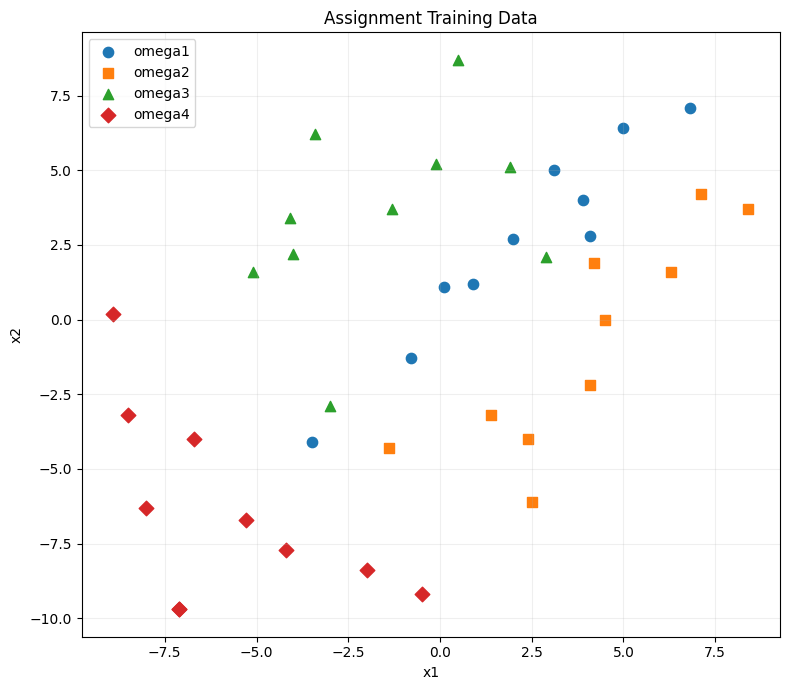

In [3]:
# Visualize the four assignment classes
fig, ax = plt.subplots(figsize=(8, 7))
markers = ["o", "s", "^", "D"]

for class_name, marker in zip(CLASS_NAMES, markers):
    pts = DATA[DATA["class"] == class_name]
    ax.scatter(pts["x1"], pts["x2"], s=55, marker=marker, label=class_name)

ax.set_title("Assignment Training Data")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "dataset_overview.png", dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)

## 2. Perceptron algorithm

The implementation starts with **w = 0**, augments each pattern with a bias coordinate, uses the standard update condition `y_i (w^T x_i) <= 0`, and counts complete passes through the training set (epochs) until an entire pass contains zero mistakes.

The required experiments are:
- ω1 vs. ω2
- ω3 vs. ω2

The difference in iteration counts is reported explicitly rather than inferred from a plot.

In [4]:
def add_bias(X):
    return np.column_stack([X, np.ones(len(X))])


def get_binary_pair(c1, c2):
    subset = DATA[DATA["class"].isin([c1, c2])].copy()
    X = subset[["x1", "x2"]].to_numpy(dtype=float)
    y_pm = np.where(subset["class"].to_numpy() == c1, 1.0, -1.0)
    return X, y_pm, subset


def perceptron_train(X_aug, y_pm, learning_rate=1.0, max_epochs=1000):
    # Start exactly from the required zero weight vector.
    w = np.zeros(X_aug.shape[1], dtype=float)
    epoch_mistakes = []

    for epoch in range(1, max_epochs + 1):
        mistakes = 0

        for xi, yi in zip(X_aug, y_pm):
            if yi * np.dot(w, xi) <= 0:
                w += learning_rate * yi * xi
                mistakes += 1

        epoch_mistakes.append(mistakes)

        if mistakes == 0:
            return w, epoch, epoch_mistakes, True

    return w, max_epochs, epoch_mistakes, False


def plot_binary_boundary(X, y_pm, w, title, filename):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(X[y_pm == 1, 0], X[y_pm == 1, 1], marker="o", label="Positive class")
    ax.scatter(X[y_pm == -1, 0], X[y_pm == -1, 1], marker="x", label="Negative class")

    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    xs = np.linspace(x_min, x_max, 400)

    if abs(w[1]) > 1e-12:
        ys = -(w[0] * xs + w[2]) / w[1]
        ax.plot(xs, ys, linewidth=2, label="Decision boundary")
    else:
        ax.axvline(-w[2] / w[0], linewidth=2, label="Decision boundary")

    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.grid(alpha=0.2)
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)

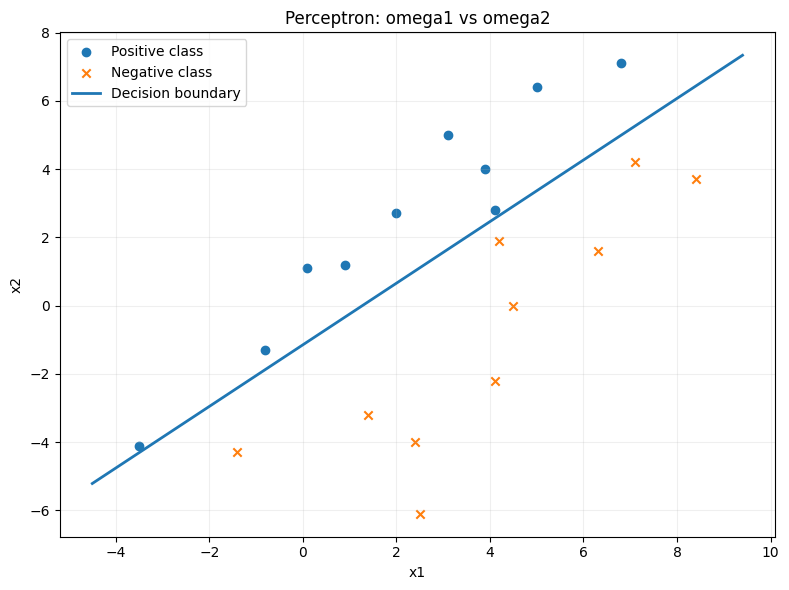

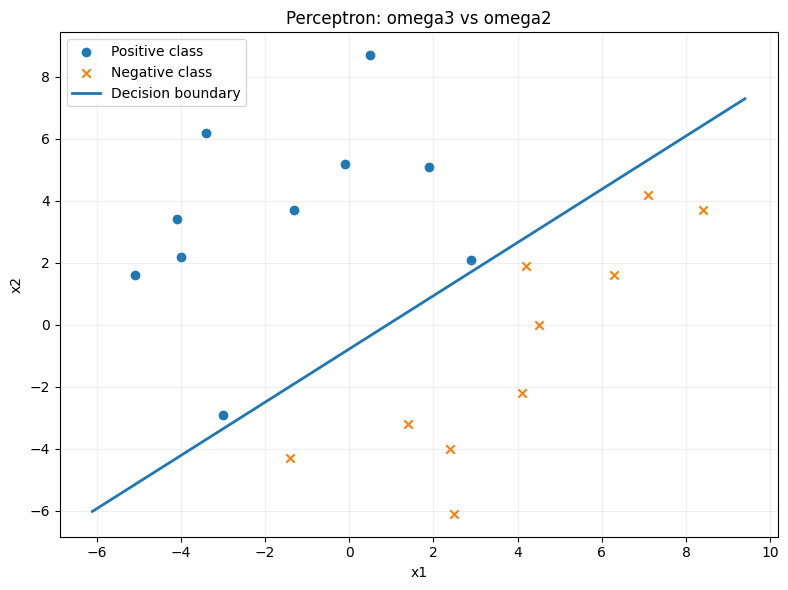

,case,positive_class,negative_class,iterations_to_convergence,converged,final_w_x1,final_w_x2,final_bias,misclassified_samples_last_epoch
0,omega1 vs omega2,omega1,omega2,9,True,-10.2,11.3,13.0,0
1,omega3 vs omega2,omega3,omega2,5,True,-5.5,6.4,5.0,0


Iteration comparison: omega1 vs omega2 = 9 epochs; omega3 vs omega2 = 5 epochs.


In [5]:
perceptron_rows = []

for c1, c2 in [("omega1", "omega2"), ("omega3", "omega2")]:
    X, y_pm, _ = get_binary_pair(c1, c2)
    w, epochs, mistakes, converged = perceptron_train(add_bias(X), y_pm)

    perceptron_rows.append({
        "case": f"{c1} vs {c2}",
        "positive_class": c1,
        "negative_class": c2,
        "iterations_to_convergence": epochs,
        "converged": converged,
        "final_w_x1": w[0],
        "final_w_x2": w[1],
        "final_bias": w[2],
        "misclassified_samples_last_epoch": mistakes[-1],
    })

    plot_binary_boundary(
        X, y_pm, w,
        f"Perceptron: {c1} vs {c2}",
        f"perceptron_{c1}_vs_{c2}.png"
    )

perceptron_results = pd.DataFrame(perceptron_rows)
perceptron_results.to_csv(OUTPUT_DIR / "perceptron_results.csv", index=False)
display(perceptron_results)

print(
    "Iteration comparison: "
    f"omega1 vs omega2 = {perceptron_results.loc[0, 'iterations_to_convergence']} epochs; "
    f"omega3 vs omega2 = {perceptron_results.loc[1, 'iterations_to_convergence']} epochs."
)

### Perceptron interpretation

For this fixed sample order, ω1 vs. ω2 converges in more epochs than ω3 vs. ω2. The difference is not a claim that one class pair is intrinsically harder under every possible sample order: perceptron convergence is sensitive to the order of presented samples and to the geometry of the separating hyperplane. Here the comparison is strictly for the required deterministic implementation and the given training order.

## 3. Least-squares (LS) criterion

For each requested binary pair, the notebook solves the linear least-squares classification problem using the Moore-Penrose pseudoinverse:

`w = X^+ y`

with targets `+1` for the first class and `-1` for the second class. Classification uses the sign of `w^T x_aug`.

In [6]:
def least_squares_train(X_aug, y_pm):
    # Moore-Penrose pseudoinverse gives a stable minimum-norm LS solution.
    w = np.linalg.pinv(X_aug) @ y_pm
    scores = X_aug @ w
    predictions = np.where(scores >= 0.0, 1.0, -1.0)
    accuracy = float(np.mean(predictions == y_pm))
    return w, predictions, scores, accuracy


ls_rows = []
for c1, c2 in [("omega1", "omega2"), ("omega3", "omega2")]:
    X, y_pm, _ = get_binary_pair(c1, c2)
    w, predictions, scores, accuracy = least_squares_train(add_bias(X), y_pm)

    ls_rows.append({
        "case": f"{c1} vs {c2}",
        "positive_class": c1,
        "negative_class": c2,
        "training_accuracy": accuracy,
        "w_x1": w[0],
        "w_x2": w[1],
        "bias": w[2],
    })

ls_results = pd.DataFrame(ls_rows)
ls_results.to_csv(OUTPUT_DIR / "least_squares_results.csv", index=False)
display(ls_results)

,case,positive_class,negative_class,training_accuracy,w_x1,w_x2,bias
0,omega1 vs omega2,omega1,omega2,0.95,-0.333919,0.287857,0.782641
1,omega3 vs omega2,omega3,omega2,0.95,-0.179877,0.137013,0.029771


## 4. Logistic Discrimination

A binary logistic discriminant is implemented directly with NumPy using the logistic sigmoid and batch gradient descent. No machine-learning library hides the requested algorithm.

Two multi-category decompositions are evaluated:

- **One-vs-rest:** four classifiers, one for each `omega_i` versus all other classes.
- **One-vs-one:** one classifier for each of the six unordered class pairs.

Because the assignment does not specify an optimizer, learning rate, or stopping threshold, these implementation choices are made explicit and kept deterministic. For linearly separable pairs, the unregularized logistic maximum-likelihood solution has no finite optimum; the code therefore uses a maximum iteration budget and records `converged=False` where appropriate.

In [7]:
def sigmoid(z):
    # Clipping keeps exp() numerically stable for large magnitudes.
    z = np.clip(z, -60.0, 60.0)
    return 1.0 / (1.0 + np.exp(-z))


def logistic_train(
    X_aug,
    y01,
    learning_rate=0.25,
    max_iterations=10000,
    tolerance=1e-8,
):
    # Batch gradient descent for unregularized binary logistic loss.
    w = np.zeros(X_aug.shape[1], dtype=float)

    for iteration in range(1, max_iterations + 1):
        p = sigmoid(X_aug @ w)
        grad = (X_aug.T @ (p - y01)) / len(y01)
        candidate = w - learning_rate * grad

        p_clip = np.clip(p, 1e-12, 1.0 - 1e-12)
        loss = float(
            -np.mean(
                y01 * np.log(p_clip)
                + (1.0 - y01) * np.log(1.0 - p_clip)
            )
        )

        if np.linalg.norm(candidate - w) <= tolerance:
            return candidate, iteration, True, loss

        w = candidate

    return w, max_iterations, False, loss


def train_one_vs_rest():
    models = {}
    rows = []

    X_all = DATA[["x1", "x2"]].to_numpy(dtype=float)
    X_aug = add_bias(X_all)
    labels = DATA["class"].to_numpy()

    for class_name in CLASS_NAMES:
        y01 = (labels == class_name).astype(float)
        w, iterations, converged, loss = logistic_train(X_aug, y01)

        probabilities = sigmoid(X_aug @ w)
        accuracy = float(np.mean((probabilities >= 0.5) == (y01 == 1)))

        models[class_name] = w
        rows.append({
            "classifier": f"{class_name} vs not {class_name}",
            "target_class": class_name,
            "training_accuracy": accuracy,
            "iterations": iterations,
            "converged": converged,
            "final_loss": loss,
        })

    return models, pd.DataFrame(rows)


def predict_one_vs_rest(models, X):
    X_aug = add_bias(X)
    probabilities = np.column_stack(
        [sigmoid(X_aug @ models[c]) for c in CLASS_NAMES]
    )
    winner_index = np.argmax(probabilities, axis=1)
    predictions = np.array([CLASS_NAMES[i] for i in winner_index])
    return predictions, probabilities


ovr_models, ovr_results = train_one_vs_rest()
ovr_results.to_csv(
    OUTPUT_DIR / "logistic_one_vs_rest_results.csv",
    index=False
)

display(ovr_results)

,classifier,target_class,training_accuracy,iterations,converged,final_loss
0,omega1 vs not omega1,omega1,0.750,444,True,0.489403
1,omega2 vs not omega2,omega2,0.925,4157,True,0.215195
2,omega3 vs not omega3,omega3,0.925,1245,True,0.313237
3,omega4 vs not omega4,omega4,1.000,10000,False,0.017750


In [8]:
# One-vs-rest multicategory training-set predictions
X_all = DATA[["x1", "x2"]].to_numpy(dtype=float)
y_all = DATA["class"].to_numpy()

ovr_predictions, ovr_probabilities = predict_one_vs_rest(ovr_models, X_all)

ovr_prediction_table = pd.DataFrame({
    "true_class": y_all,
    "ovr_prediction": ovr_predictions,
})

for i, class_name in enumerate(CLASS_NAMES):
    ovr_prediction_table[f"probability_{class_name}"] = ovr_probabilities[:, i]

display(ovr_prediction_table)

ovr_accuracy = float(np.mean(ovr_predictions == y_all))
print(f"Overall one-vs-rest training accuracy: {ovr_accuracy:.3f}")
ovr_prediction_table.to_csv(
    OUTPUT_DIR / "logistic_one_vs_rest_predictions.csv",
    index=False
)

,true_class,ovr_prediction,probability_omega1,probability_omega2,probability_omega3,probability_omega4
0,omega1,omega1,0.246979,0.015730,0.182665,1.604869e-07
1,omega1,omega1,0.602590,0.419890,0.339453,5.790471e-17
2,omega1,omega4,0.100253,0.007007,0.043280,3.123198e-01
3,omega1,omega1,0.333187,0.047799,0.210597,3.966695e-10
4,omega1,omega1,0.390440,0.334675,0.109429,7.594315e-12
5,omega1,omega1,0.432551,0.039731,0.396663,1.352546e-12
6,omega1,omega1,0.178325,0.025202,0.073243,3.850030e-05
7,omega1,omega1,0.266563,0.035675,0.147078,3.219706e-08
8,omega1,omega1,0.530842,0.128321,0.411270,4.609071e-15
9,omega1,omega1,0.422667,0.159725,0.211009,1.587181e-12


Overall one-vs-rest training accuracy: 0.900


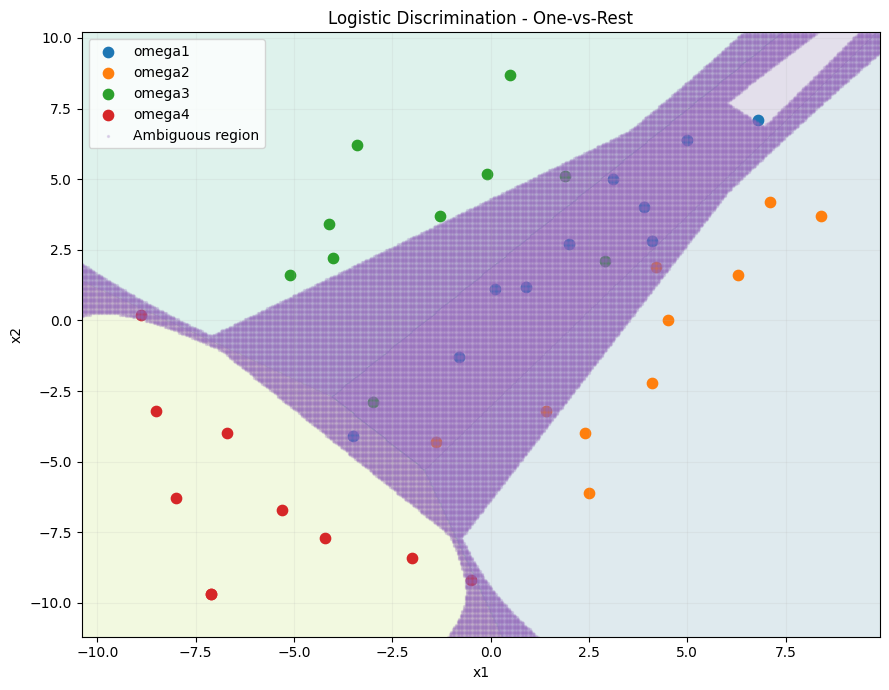

Flagged 60,677 grid points as potentially ambiguous.


In [9]:
# One-vs-rest decision regions and ambiguity analysis
x1_min, x1_max = DATA["x1"].min() - 1.5, DATA["x1"].max() + 1.5
x2_min, x2_max = DATA["x2"].min() - 1.5, DATA["x2"].max() + 1.5

xx, yy = np.meshgrid(
    np.linspace(x1_min, x1_max, 500),
    np.linspace(x2_min, x2_max, 500)
)
grid = np.column_stack([xx.ravel(), yy.ravel()])

grid_predictions, grid_probabilities = predict_one_vs_rest(ovr_models, grid)
sorted_probabilities = np.sort(grid_probabilities, axis=1)
max_probability = sorted_probabilities[:, -1]
top2_margin = sorted_probabilities[:, -1] - sorted_probabilities[:, -2]

# A point is marked ambiguous when the best class is weakly supported
# or when the top two class probabilities are very close.
ambiguous_mask = (max_probability < 0.60) | (top2_margin < 0.10)

class_to_int = {class_name: i for i, class_name in enumerate(CLASS_NAMES)}
region_values = np.array([class_to_int[p] for p in grid_predictions]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 7))
ax.contourf(
    xx, yy, region_values,
    levels=np.arange(-0.5, len(CLASS_NAMES), 1),
    alpha=0.15
)

for class_name in CLASS_NAMES:
    pts = DATA[DATA["class"] == class_name]
    ax.scatter(pts["x1"], pts["x2"], s=55, label=class_name)

ax.scatter(
    grid[ambiguous_mask, 0],
    grid[ambiguous_mask, 1],
    s=2,
    alpha=0.20,
    label="Ambiguous region"
)

ax.set_title("Logistic Discrimination - One-vs-Rest")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.grid(alpha=0.15)
ax.legend()
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "logistic_one_vs_rest_regions.png",
    dpi=220,
    bbox_inches="tight"
)
plt.show()
plt.close(fig)

ovr_ambiguous = pd.DataFrame({
    "x1": grid[ambiguous_mask, 0],
    "x2": grid[ambiguous_mask, 1],
    "max_probability": max_probability[ambiguous_mask],
    "probability_margin_top2": top2_margin[ambiguous_mask],
    "predicted_class": grid_predictions[ambiguous_mask],
})

ovr_ambiguous.to_csv(
    OUTPUT_DIR / "logistic_one_vs_rest_ambiguous_regions.csv",
    index=False
)

print(f"Flagged {len(ovr_ambiguous):,} grid points as potentially ambiguous.")

## 5. One-vs-one Logistic Discrimination

For each pair, the first class in lexicographic order is encoded as the positive class. The six pairwise decisions are combined by majority voting. A grid point is considered categorically ambiguous when multiple classes receive the same maximum vote count.

This directly operationalizes the assignment's `ωi vs. ωj` requirement for all class pairs.

In [10]:
def train_one_vs_one():
    models = {}
    rows = []

    for c1, c2 in combinations(CLASS_NAMES, 2):
        subset = DATA[DATA["class"].isin([c1, c2])].copy()
        X = subset[["x1", "x2"]].to_numpy(dtype=float)
        y01 = (subset["class"].to_numpy() == c1).astype(float)

        X_aug = add_bias(X)
        w, iterations, converged, loss = logistic_train(X_aug, y01)

        models[(c1, c2)] = w
        probabilities = sigmoid(X_aug @ w)
        predictions = np.where(probabilities >= 0.5, c1, c2)
        accuracy = float(np.mean(predictions == subset["class"].to_numpy()))

        rows.append({
            "pair": f"{c1} vs {c2}",
            "positive_class": c1,
            "negative_class": c2,
            "training_accuracy": accuracy,
            "iterations": iterations,
            "converged": converged,
            "final_loss": loss,
        })

    return models, pd.DataFrame(rows)


def pairwise_probability(models, c1, c2, X):
    first, second = sorted((c1, c2))
    w = models[(first, second)]
    probability_first = sigmoid(add_bias(X) @ w)
    return probability_first if c1 == first else 1.0 - probability_first


def predict_one_vs_one(models, X):
    votes = np.zeros((len(X), len(CLASS_NAMES)), dtype=int)
    class_index = {class_name: i for i, class_name in enumerate(CLASS_NAMES)}

    for c1, c2 in combinations(CLASS_NAMES, 2):
        p_c1 = pairwise_probability(models, c1, c2, X)
        winner_is_c1 = p_c1 >= 0.5

        votes[winner_is_c1, class_index[c1]] += 1
        votes[~winner_is_c1, class_index[c2]] += 1

    max_votes = votes.max(axis=1)
    predictions = np.array(
        [CLASS_NAMES[i] for i in np.argmax(votes, axis=1)]
    )
    tied = np.sum(votes == max_votes[:, None], axis=1) > 1

    return predictions, votes, tied


ovo_models, ovo_results = train_one_vs_one()
ovo_results.to_csv(
    OUTPUT_DIR / "logistic_one_vs_one_results.csv",
    index=False
)

display(ovo_results)

,pair,positive_class,negative_class,training_accuracy,iterations,converged,final_loss
0,omega1 vs omega2,omega1,omega2,1.0,10000,False,0.005305
1,omega1 vs omega3,omega1,omega3,0.9,962,True,0.325618
2,omega1 vs omega4,omega1,omega4,1.0,10000,False,0.029952
3,omega2 vs omega3,omega2,omega3,1.0,10000,False,0.002469
4,omega2 vs omega4,omega2,omega4,1.0,10000,False,0.006054
5,omega3 vs omega4,omega3,omega4,1.0,10000,False,0.007358


,true_class,ovo_prediction,ovo_vote_tie,votes_omega1,votes_omega2,votes_omega3,votes_omega4
0,omega1,omega1,False,3,1,2,0
1,omega1,omega1,False,3,1,2,0
2,omega1,omega1,False,3,0,1,2
3,omega1,omega1,False,3,1,2,0
4,omega1,omega1,False,3,1,2,0
5,omega1,omega1,False,3,1,2,0
6,omega1,omega1,False,3,1,2,0
7,omega1,omega1,False,3,1,2,0
8,omega1,omega1,False,3,1,2,0
9,omega1,omega1,False,3,1,2,0


Overall one-vs-one training accuracy: 0.950


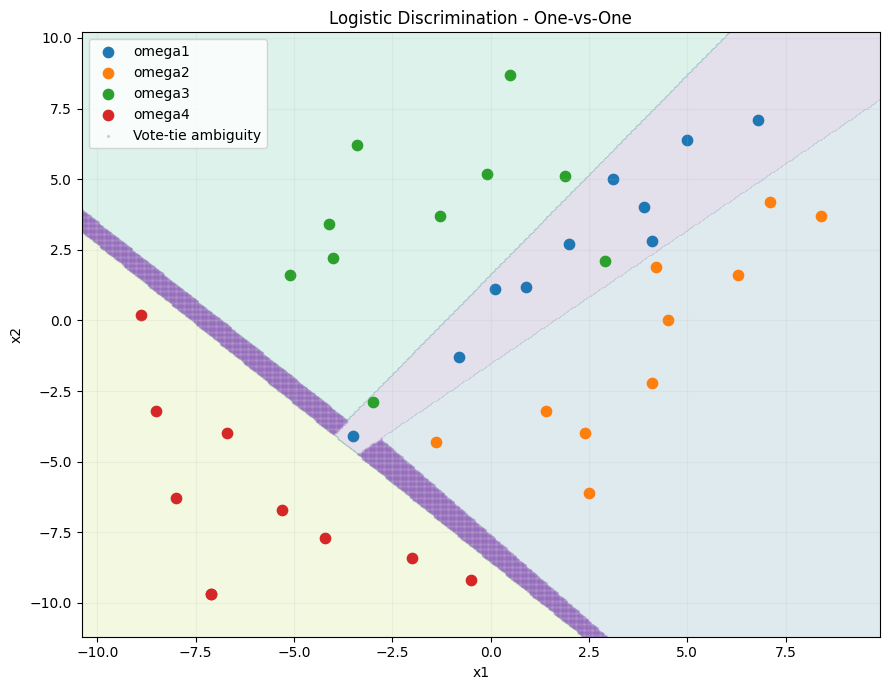

Flagged 6,274 one-vs-one vote-tie grid points.


In [11]:
# One-vs-one multicategory predictions and ambiguity map
ovo_predictions, ovo_votes, ovo_tied = predict_one_vs_one(ovo_models, X_all)

ovo_prediction_table = pd.DataFrame({
    "true_class": y_all,
    "ovo_prediction": ovo_predictions,
    "ovo_vote_tie": ovo_tied,
})

for i, class_name in enumerate(CLASS_NAMES):
    ovo_prediction_table[f"votes_{class_name}"] = ovo_votes[:, i]

display(ovo_prediction_table)

ovo_accuracy = float(np.mean(ovo_predictions == y_all))
print(f"Overall one-vs-one training accuracy: {ovo_accuracy:.3f}")

ovo_prediction_table.to_csv(
    OUTPUT_DIR / "logistic_one_vs_one_predictions.csv",
    index=False
)

grid_ovo_predictions, grid_ovo_votes, grid_ovo_tied = predict_one_vs_one(
    ovo_models, grid
)

region_ovo_values = np.array(
    [class_to_int[p] for p in grid_ovo_predictions]
).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 7))
ax.contourf(
    xx, yy, region_ovo_values,
    levels=np.arange(-0.5, len(CLASS_NAMES), 1),
    alpha=0.15
)

for class_name in CLASS_NAMES:
    pts = DATA[DATA["class"] == class_name]
    ax.scatter(pts["x1"], pts["x2"], s=55, label=class_name)

ax.scatter(
    grid[grid_ovo_tied, 0],
    grid[grid_ovo_tied, 1],
    s=2,
    alpha=0.25,
    label="Vote-tie ambiguity"
)

ax.set_title("Logistic Discrimination - One-vs-One")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.grid(alpha=0.15)
ax.legend()
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "logistic_one_vs_one_regions.png",
    dpi=220,
    bbox_inches="tight"
)
plt.show()
plt.close(fig)

ovo_ambiguous = pd.DataFrame({
    "x1": grid[grid_ovo_tied, 0],
    "x2": grid[grid_ovo_tied, 1],
    "ambiguity_type": "vote tie",
})
ovo_ambiguous.to_csv(
    OUTPUT_DIR / "logistic_one_vs_one_ambiguous_regions.csv",
    index=False
)

print(f"Flagged {len(ovo_ambiguous):,} one-vs-one vote-tie grid points.")

## 6. Final experiment summary

The tables below consolidate the assignment's requested outputs into clean CSV artifacts. The notebook deliberately distinguishes:

- **Perceptron convergence iterations** (the explicit requirement in section 1);
- **LS training accuracy**;
- **Logistic optimizer status and training accuracy**;
- **ambiguity regions** identified from the multicategory decision system.

In [12]:
experiment_summary = pd.DataFrame([
    {
        "experiment": "Perceptron omega1 vs omega2",
        "metric": "iterations_to_convergence",
        "value": perceptron_results.loc[0, "iterations_to_convergence"],
    },
    {
        "experiment": "Perceptron omega3 vs omega2",
        "metric": "iterations_to_convergence",
        "value": perceptron_results.loc[1, "iterations_to_convergence"],
    },
    {
        "experiment": "Least squares omega1 vs omega2",
        "metric": "training_accuracy",
        "value": ls_results.loc[0, "training_accuracy"],
    },
    {
        "experiment": "Least squares omega3 vs omega2",
        "metric": "training_accuracy",
        "value": ls_results.loc[1, "training_accuracy"],
    },
    {
        "experiment": "Logistic one-vs-rest",
        "metric": "mean_binary_training_accuracy",
        "value": ovr_results["training_accuracy"].mean(),
    },
    {
        "experiment": "Logistic one-vs-one",
        "metric": "mean_pairwise_training_accuracy",
        "value": ovo_results["training_accuracy"].mean(),
    },
])

experiment_summary.to_csv(
    OUTPUT_DIR / "experiment_summary.csv",
    index=False
)

display(experiment_summary)

print("\nKey Perceptron result:")
print(perceptron_results[
    ["case", "iterations_to_convergence", "converged"]
].to_string(index=False))

print("\nKey Logistic optimizer-status result:")
print(ovo_results[
    ["pair", "training_accuracy", "iterations", "converged"]
].to_string(index=False))

,experiment,metric,value
0,Perceptron omega1 vs omega2,iterations_to_convergence,9.000000
1,Perceptron omega3 vs omega2,iterations_to_convergence,5.000000
2,Least squares omega1 vs omega2,training_accuracy,0.950000
3,Least squares omega3 vs omega2,training_accuracy,0.950000
4,Logistic one-vs-rest,mean_binary_training_accuracy,0.900000
5,Logistic one-vs-one,mean_pairwise_training_accuracy,0.983333



Key Perceptron result:
            case  iterations_to_convergence  converged
omega1 vs omega2                          9       True
omega3 vs omega2                          5       True

Key Logistic optimizer-status result:
            pair  training_accuracy  iterations  converged
omega1 vs omega2                1.0       10000      False
omega1 vs omega3                0.9         962       True
omega1 vs omega4                1.0       10000      False
omega2 vs omega3                1.0       10000      False
omega2 vs omega4                1.0       10000      False
omega3 vs omega4                1.0       10000      False


## 7. One-click artifact export (final cell)

This cell is intentionally the last executable cell. It:

1. writes a manifest of all generated files;
2. includes the exact assignment dataset CSV;
3. includes every CSV and PNG result;
4. includes a copy of the corrected Python script when it exists beside the notebook;
5. creates a ZIP archive;
6. triggers an automatic Google Colab download when running inside Colab.

No manual file hunting is required after execution.

In [13]:
# Final one-click export cell
manifest_paths = sorted(
    p for p in OUTPUT_DIR.rglob("*")
    if p.is_file() and p.name != "artifact_manifest.csv"
)

manifest = pd.DataFrame({
    "artifact": [p.name for p in manifest_paths],
    "relative_path": [str(p.relative_to(OUTPUT_DIR)) for p in manifest_paths],
})
manifest.to_csv(OUTPUT_DIR / "artifact_manifest.csv", index=False)

# Generate a compact standalone script from the canonical source file when available.
source_script_candidates = [
    BASE_DIR / "assignment3_solution.py",
    Path("/content/assignment3_solution.py"),
]
for source_script in source_script_candidates:
    if source_script.exists():
        shutil.copy2(source_script, OUTPUT_DIR / "assignment3_solution.py")
        break

zip_path = BASE_DIR / "assignment3_outputs.zip"
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(
    zip_path,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as archive:
    for path in sorted(OUTPUT_DIR.rglob("*")):
        if path.is_file():
            archive.write(
                path,
                arcname=str(path.relative_to(OUTPUT_DIR.parent))
            )

print(f"Output directory: {OUTPUT_DIR}")
print(f"ZIP archive: {zip_path}")
print("\nGenerated artifacts:")
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        print(f" - {path.relative_to(OUTPUT_DIR)}")

try:
    from google.colab import files
    files.download(str(zip_path))
except ImportError:
    print("\nNot running in Google Colab; the ZIP file remains available at:")
    print(zip_path)

Output directory: /content/assignment3_outputs
ZIP archive: /content/assignment3_outputs.zip

Generated artifacts:
 - artifact_manifest.csv
 - assignment3_dataset.csv
 - dataset_overview.png
 - experiment_summary.csv
 - least_squares_results.csv
 - logistic_one_vs_one_ambiguous_regions.csv
 - logistic_one_vs_one_predictions.csv
 - logistic_one_vs_one_regions.png
 - logistic_one_vs_one_results.csv
 - logistic_one_vs_rest_ambiguous_regions.csv
 - logistic_one_vs_rest_predictions.csv
 - logistic_one_vs_rest_regions.png
 - logistic_one_vs_rest_results.csv
 - perceptron_omega1_vs_omega2.png
 - perceptron_omega3_vs_omega2.png
 - perceptron_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>